# HealthConnect Clinic — Week 4 Exploratory Data Analysis & Initial Analysis Notebook
**Data Analytics Track | No-Show & Appointment Analytics**

This notebook is the Data Analytics track Week 4 output for the AnalystLab Africa HealthConnect Experience Lab:
dataset inspection, data-quality assessment, key-variable identification, and the
groundwork behind the business questions and KPIs defined in `docs/HealthConnect_Week4_Analysis_Document.docx`.

**Data sources:**
- `data/HealthConnect_Appointment_Data.csv` — 5,000 appointment records, 18 fields
- `data/HealthConnect_Data_Dictionary.xlsx` — field-level definitions and notes


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/HealthConnect_Appointment_Data.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Loaded 5,000 rows x 18 columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 1. Data Dictionary Review (Step 5)

Reviewed first, before touching the data, to set expectations for types and valid values.
See Section 5 of the Week 4 Analysis Document for the full field-by-field table. Key points carried
into this analysis:

- `appointment_outcome` is the target variable: **Attended / No-Show / Cancelled**
- `reminder_channel` is expected to be blank when `reminder_sent == "No"`
- `previous_no_shows` should never exceed `previous_appointments`
- `booking_lead_days` should equal `appointment_date - booking_date`
- `age_group` should be a deterministic band of `age`


In [2]:
dictionary = pd.read_excel('../data/HealthConnect_Data_Dictionary.xlsx')
dictionary


,Variable,Data Type,Description,Example,Notes
0,appointment_id,Text,Unique appointment identifier,HC-00001,Primary key
1,patient_id,Text,Anonymised patient identifier,P-0421,May appear across multiple appointments
2,gender,Text,Recorded gender category,Female,Synthetic and anonymised
3,age,Integer,Patient age in years,34,Adult patients only
4,age_group,Text,Age band derived from age,25-34,Provided for descriptive analysis
5,appointment_type,Text,Type of scheduled appointment,Follow-up,Four appointment categories
6,booking_date,Date,Date appointment was booked,2025-04-10 00:00:00,ISO format
7,appointment_date,Date,Scheduled appointment date,2025-04-24 00:00:00,ISO format
8,appointment_day,Text,Day of week for appointment,Thursday,Derived from appointment date
9,appointment_time,Text,Appointment time period,Morning,"Morning, Afternoon, Evening"


## 2. Dataset Inspection (Step 6)

In [3]:
print("Shape:", df.shape)
print()
df.dtypes


Shape: (5000, 18)



appointment_id                      str
patient_id                          str
gender                              str
age                               int64
age_group                           str
appointment_type                    str
booking_date             datetime64[us]
appointment_date         datetime64[us]
appointment_day                     str
appointment_time                    str
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                       str
reminder_channel                    str
distance_to_clinic_km           float64
waiting_time_minutes            float64
appointment_outcome                 str
dtype: object

In [4]:
print("Unique patients:", df['patient_id'].nunique())
print("Total appointments:", len(df))
print("Avg appointments per patient:", round(len(df) / df['patient_id'].nunique(), 2))
print()
print("Appointment date range:", df['appointment_date'].min().date(), "to", df['appointment_date'].max().date())
print("Booking date range:", df['booking_date'].min().date(), "to", df['booking_date'].max().date())


Unique patients: 1696
Total appointments: 5000
Avg appointments per patient: 2.95

Appointment date range: 2025-01-01 to 2026-06-30
Booking date range: 2024-11-07 to 2026-06-27


In [5]:
df[['age','booking_lead_days','previous_appointments','previous_no_shows',
    'distance_to_clinic_km','waiting_time_minutes']].describe().round(2)


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.00,5000.00,5000.00,5000.00,4910.00,4940.00
mean,48.79,29.64,3.01,0.54,10.11,24.19
std,18.14,17.40,1.74,0.75,6.59,10.86
min,18.00,0.00,0.00,0.00,0.50,2.00
25%,33.00,15.00,2.00,0.00,5.30,17.00
50%,49.00,30.00,3.00,0.00,8.70,24.00
75%,64.00,45.00,4.00,1.00,13.50,32.00
max,80.00,60.00,11.00,5.00,45.00,68.00


## 3. Data-Quality Assessment (Step 7)

### 3.1 Completeness

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
quality[quality['missing_count'] > 0]


,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


In [7]:
# Confirm reminder_channel missingness is fully explained by reminder_sent == 'No'
check = df[df['reminder_sent'] == 'No']['reminder_channel'].isnull().sum()
total_no = (df['reminder_sent'] == 'No').sum()
print(f"Rows with reminder_sent='No': {total_no}")
print(f"...of which reminder_channel is null: {check}")
print("Fully explained:", check == total_no == df['reminder_channel'].isnull().sum())


Rows with reminder_sent='No': 1366
...of which reminder_channel is null: 1366
Fully explained: True


### 3.2 Duplicates

In [8]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate appointment_id values:", df['appointment_id'].duplicated().sum())


Fully duplicated rows: 0
Duplicate appointment_id values: 0


### 3.3 Validity & Consistency Checks

In [9]:
checks = {}

# previous_no_shows should never exceed previous_appointments
checks['previous_no_shows > previous_appointments'] = (df['previous_no_shows'] > df['previous_appointments']).sum()

# booking_lead_days should equal appointment_date - booking_date
recomputed_lead = (df['appointment_date'] - df['booking_date']).dt.days
checks['booking_lead_days mismatch'] = (recomputed_lead != df['booking_lead_days']).sum()

# appointment_day should match the actual weekday of appointment_date
checks['appointment_day mismatch'] = (df['appointment_date'].dt.day_name() != df['appointment_day']).sum()

# age_group should match a deterministic band of age
def band(a):
    if a < 25: return '18-24'
    if a < 35: return '25-34'
    if a < 45: return '35-44'
    if a < 55: return '45-54'
    if a < 65: return '55-64'
    return '65+'
checks['age_group mismatch'] = (df['age'].apply(band) != df['age_group']).sum()

# negative values where they shouldn't exist
checks['negative booking_lead_days'] = (df['booking_lead_days'] < 0).sum()
checks['negative distance_to_clinic_km'] = (df['distance_to_clinic_km'] < 0).sum()
checks['negative waiting_time_minutes'] = (df['waiting_time_minutes'] < 0).sum()

pd.Series(checks, name='violations').to_frame()


,violations
previous_no_shows > previous_appointments,0
booking_lead_days mismatch,0
appointment_day mismatch,0
age_group mismatch,0
negative booking_lead_days,0
negative distance_to_clinic_km,0
negative waiting_time_minutes,0


All consistency checks pass with **zero violations**. The dataset's derived fields
(`booking_lead_days`, `appointment_day`, `age_group`) are internally consistent with their
source fields, and business-rule fields (`previous_no_shows` vs. `previous_appointments`) hold.

### 3.4 Anomalies for Follow-Up

In [10]:
print("Appointments recorded on a Sunday:", (df['appointment_day'] == 'Sunday').sum())
print()
print(df['gender'].value_counts())


Appointments recorded on a Sunday: 737

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64


- **Sunday appointments (737 rows):** internally consistent (date ↔ weekday match), but
  worth confirming against actual clinic operating-hours policy before any hours-based segmentation.
- **`Prefer not to say` gender (108 rows, 2.2%):** kept as its own category rather than imputed or dropped.

**Overall verdict:** data quality is high. No rows need to be dropped. Missingness is limited,
mostly explainable by business logic, and concentrated in two non-critical numeric fields.

## 4. Identifying Important Variables (Step 8)

To prioritise variables for deeper analysis, we compare `appointment_outcome` rates across
each candidate field.

In [11]:
def outcome_rate_table(col):
    t = pd.crosstab(df[col], df['appointment_outcome'], normalize='index').round(3)
    t['n'] = df[col].value_counts()
    return t.sort_values('n', ascending=False)

print("Overall outcome split:")
print(df['appointment_outcome'].value_counts(normalize=True).round(3))


Overall outcome split:
appointment_outcome
No-Show      0.485
Attended     0.463
Cancelled    0.053
Name: proportion, dtype: float64


In [12]:
outcome_rate_table('reminder_sent')


appointment_outcome,Attended,Cancelled,No-Show,n
reminder_sent,,,,
Yes,0.476,0.050,0.474,3634
No,0.427,0.059,0.514,1366


In [13]:
outcome_rate_table('reminder_channel')


appointment_outcome,Attended,Cancelled,No-Show,n
reminder_channel,,,,
SMS,0.496,0.046,0.458,2000
WhatsApp,0.446,0.056,0.498,1101
Email,0.465,0.051,0.484,533


In [14]:
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,45,60],
                           labels=['0-7','8-14','15-30','31-45','46-60'])
outcome_rate_table('lead_bucket')


appointment_outcome,Attended,Cancelled,No-Show,n
lead_bucket,,,,
15-30,0.517,0.051,0.432,1333
31-45,0.405,0.056,0.538,1258
46-60,0.272,0.051,0.677,1167
0-7,0.666,0.056,0.278,640
8-14,0.618,0.047,0.336,602


In [15]:
outcome_rate_table('previous_no_shows')


appointment_outcome,Attended,Cancelled,No-Show,n
previous_no_shows,,,,
0,0.505,0.060,0.435,2921
1,0.422,0.043,0.535,1548
2,0.363,0.043,0.594,438
3,0.295,0.026,0.679,78
4,0.333,0.000,0.667,12
5,0.000,0.000,1.000,3


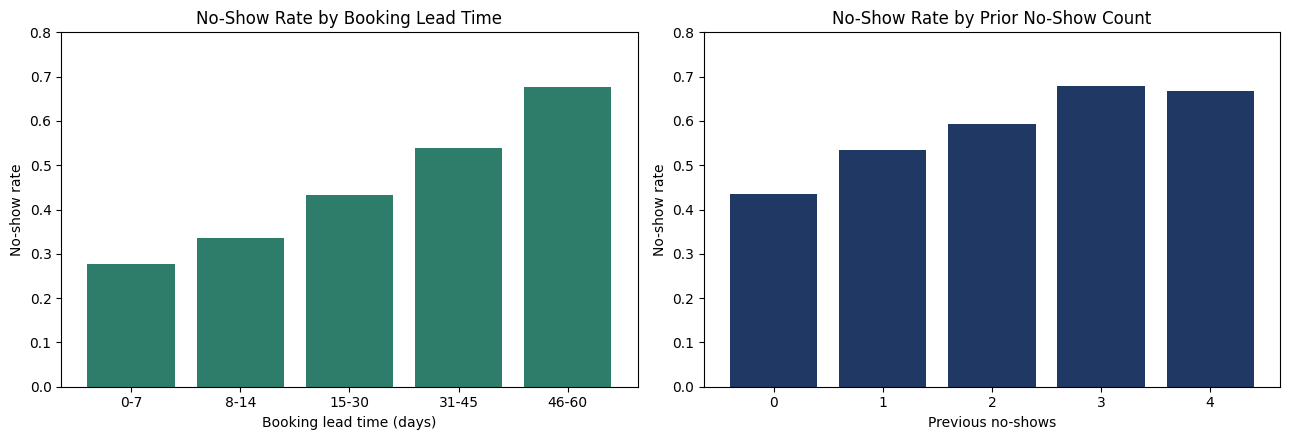

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

lead_noshow = df.groupby('lead_bucket', observed=True)['appointment_outcome'] \
                .apply(lambda s: (s == 'No-Show').mean())
axes[0].bar(lead_noshow.index.astype(str), lead_noshow.values, color='#2E7D6B')
axes[0].set_title('No-Show Rate by Booking Lead Time')
axes[0].set_xlabel('Booking lead time (days)')
axes[0].set_ylabel('No-show rate')
axes[0].set_ylim(0, 0.8)

prior_noshow = df[df['previous_no_shows'] <= 4].groupby('previous_no_shows')['appointment_outcome'] \
                 .apply(lambda s: (s == 'No-Show').mean())
axes[1].bar(prior_noshow.index.astype(str), prior_noshow.values, color='#1F3864')
axes[1].set_title('No-Show Rate by Prior No-Show Count')
axes[1].set_xlabel('Previous no-shows')
axes[1].set_ylabel('No-show rate')
axes[1].set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig('../outputs/noshow_by_leadtime_and_history.png', dpi=120)
plt.show()


In [17]:
weak_signal_cols = ['appointment_type', 'age_group', 'appointment_time', 'gender']
for col in weak_signal_cols:
    print(f"--- {col} ---")
    print(outcome_rate_table(col)[['No-Show']].T)
    print()


--- appointment_type ---
appointment_type     General Consultation  Follow-up  Specialist Consultation  Diagnostic Test
appointment_outcome                                                                           
No-Show                             0.466      0.512                    0.474            0.497

--- age_group ---
age_group              65+  35-44  55-64  45-54  25-34  18-24
appointment_outcome                                          
No-Show              0.451  0.484  0.507   0.48  0.507  0.502

--- appointment_time ---
appointment_time     Morning  Afternoon  Evening
appointment_outcome                             
No-Show                0.481      0.484    0.498

--- gender ---
gender               Female   Male  Prefer not to say
appointment_outcome                                  
No-Show               0.484  0.487              0.435



**Summary of signal strength** (full detail in Section 8 of the Week 4 Analysis Document):

| Variable | Signal | Note |
|---|---|---|
| `booking_lead_days` | **Strong** | No-show rate: 28% (0–7 days) → 68% (46–60 days) |
| `previous_no_shows` | **Strong** | No-show rate: 44% (0 prior) → 68–100% (3+ prior) |
| `reminder_sent` | Moderate | 47.4% (sent) vs 51.4% (not sent) |
| `reminder_channel` | Weak–moderate | SMS lowest (45.8%) vs WhatsApp (49.8%) |
| `appointment_type`, `age_group`, `appointment_time`, `gender` | Weak | Rates cluster within a few points across categories |


## 5. From Findings to Business Questions & KPIs

The patterns above directly motivate the five business questions and five KPIs defined in
Sections 9–10 of the Week 4 Analysis Document (`docs/HealthConnect_Week4_Analysis_Document.docx`):

- **Q1/Q2** (no-show rate & drivers) are informed directionally by the lead-time and prior-no-show
  charts above.
- **Q4** (reminder effectiveness) is informed directionally by the `reminder_sent` /
  `reminder_channel` tables above, and maps to the **Reminder Effectiveness** KPI.
- **Q5** (segment targeting) is supported by the `previous_no_shows` breakdown, which maps
  to the **Repeat No-Show Rate** KPI.

**Per the Week 4 brief, KPIs are identified and justified at this stage only** — they are not
calculated, analysed, or visualised as formal metrics yet. That work is scoped for a later stage
of the project. The table below is the identification/justification list (matches the analysis
document); no KPI values are computed here.

| KPI | Linked question(s) | Why it's relevant |
|---|---|---|
| No-Show Rate | Q1 | Primary metric for the core business problem |
| Attendance Rate | Q1 | Complements no-show rate for capacity planning |
| Cancellation Rate | Q1, Q3 | Separates planned vs. unplanned non-attendance |
| Reminder Effectiveness | Q4 | Measures whether reminders (and which channel) change attendance |
| Repeat No-Show Rate | Q2, Q5 | Identifies a high-risk segment for targeted intervention |

*(The exploratory rate tables in Section 4 above are diagnostic exploration to identify important
variables — Task 3 of the brief — not KPI calculation. They're kept because they're what surfaced
the drivers that justify the KPIs, but they should not be read as the KPIs themselves being
"calculated.")*


## 6. Next Steps (Week 2 preview)

1. Statistical significance testing (chi-square / logistic regression) on the strong and
   moderate-signal variables identified above.
2. Interaction analysis — e.g. does the lead-time effect hold within each `previous_no_shows` band?
3. Document a missing-data handling rule for `distance_to_clinic_km` and `waiting_time_minutes`
   before any modelling step.
4. Confirm the Sunday-appointment question with a stakeholder (Section 3.4 / 7.3).
5. Draft the operations-facing KPI summary and initial intervention recommendations.

See `docs/README.md` for full project navigation and `docs/HealthConnect_Week4_Analysis_Document.docx`
for the complete Week 4 writeup (brief, role, business questions, KPIs, assumptions/limitations/risks).
